# KBO 2022~2026 데이터 전처리 & 가을야구 진출 예측
**모델**: Logistic + Random Forest + Gradient Boosting 앙상블  
**데이터**: 2022(완료) · 2023(완료) · 2024(완료) · 2025(완료) · 2026(진행중)  
**기준일**: 2026-04-24 | 팀당 약 22경기 진행  

| CELL | 내용 |
|------|------|
| 1 | 라이브러리 & 환경 설정 |
| 2 | 전처리 유틸리티 함수 |
| 3 | 카테고리별 전처리 함수 (12종) |
| 4 | 데이터 로드 (processed CSV → data dict) |
| 5 | 인사이트 분석 테이블 생성 (마스터 JOIN) |
| 6 | 실시간 크롤링 (2026 자정 자동 업데이트) |
| 7 | 탐색적 데이터 분석 EDA |
| 8 | 가을야구 진출 예측 (앙상블 ML) |
| 9 | 심층 분석 — 4월 예측력 · 팀 클러스터링 · 선수이동 영향 |
| 10 | 최종 결론 출력 |

## CELL 1 · 라이브러리 & 환경 설정

In [6]:
# !pip install pandas numpy scikit-learn matplotlib seaborn requests beautifulsoup4 schedule
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, platform, os, time
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneGroupOut
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score

# ── 한글 폰트 ──────────────────────────────────────────────────
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    try:
        fp = [f.fname for f in fm.fontManager.ttflist if 'Nanum' in f.name][0]
        plt.rcParams['font.family'] = fm.FontProperties(fname=fp).get_name()
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print("✅ 라이브러리 OK")
print(f"   pandas {pd.__version__} / numpy {np.__version__}")

✅ 라이브러리 OK
   pandas 3.0.2 / numpy 2.4.4


## CELL 2 · 전처리 유틸리티 함수

In [7]:
TEAM_NAME_MAP = {
    "SK":"SSG","SK와이번스":"SSG","SSG랜더스":"SSG",
    "KIA타이거즈":"KIA","LG트윈스":"LG","KT위즈":"KT",
    "두산베어스":"두산","삼성라이온즈":"삼성","롯데자이언츠":"롯데",
    "NC다이노스":"NC","키움히어로즈":"키움","한화이글스":"한화",
    "히어로즈":"키움","넥센":"키움",
}

def read_csv_safe(path):
    for enc in ['utf-8-sig','utf-8','cp949','euc-kr']:
        try: return pd.read_csv(path, encoding=enc)
        except: continue
    raise ValueError(f"읽기 실패: {path}")

def normalize_team(name):
    return TEAM_NAME_MAP.get(str(name).strip(), str(name).strip())

def parse_ip(s):
    """'173 1/3' → 173.333""";s=str(s).strip()
    if s in ['-','','nan','NaN']: return np.nan
    if '/' in s:
        parts=s.split(); w=int(parts[0]) if len(parts)>1 else 0
        n,d=parts[-1].split('/'); return round(w+int(n)/int(d),4)
    try: return float(s)
    except: return np.nan

def parse_dash(df, cols):
    """'-' 문자 → NaN 변환 후 숫자 타입 변환""";df=df.copy()
    for c in cols:
        if c in df.columns:
            df[c]=pd.to_numeric(df[c].astype(str).replace('-',np.nan),errors='coerce')
    return df

def parse_record(s):   return s.str.extract(r'(\d+)-(\d+)-(\d+)').astype(float)
def parse_r10(s):       return s.str.extract(r'(\d+)승(\d+)무(\d+)패').astype(float)

def pythagorean_wp(rs, ra, exp=1.83):
    rs,ra=np.array(rs,float),np.array(ra,float)
    return np.where((rs>0)&(ra>0), rs**exp/(rs**exp+ra**exp), np.nan)

# ── 파생 지표 ──────────────────────────────────────────────────
def bat_drv(df):
    """타자 파생 지표 추가""";df=df.copy()
    if all(c in df.columns for c in ['HR','AB']):
        df['HR/AB']=(df['HR']/df['AB'].replace(0,np.nan)).round(4)
    if all(c in df.columns for c in ['H','HR','AB','SO','SF']):
        denom=df['AB']-df['SO']-df['HR']+df['SF']
        df['BABIP']=((df['H']-df['HR'])/denom.replace(0,np.nan)).round(3)
    if all(c in df.columns for c in ['BB','SO']):
        df['BB/K']=(df['BB']/df['SO'].replace(0,np.nan)).round(3)
    if all(c in df.columns for c in ['SLG','AVG']):
        df['ISO']=(df['SLG']-df['AVG']).round(3)
    if all(c in df.columns for c in ['BB','HBP','H','2B','3B','HR','PA']):
        df['wOBA']=((0.69*df['BB']+0.72*df['HBP']
                     +0.89*(df['H']-df['2B']-df['3B']-df['HR'])
                     +1.27*df['2B']+1.62*df['3B']+2.10*df['HR'])
                    /df['PA'].replace(0,np.nan)).round(3)
    return df

def pit_drv(df):
    """투수 파생 지표 추가""";df=df.copy()
    if all(c in df.columns for c in ['SO','IP','BB','HR','HBP']):
        ip=df['IP'].replace(0,np.nan)
        df['K/9']   =(df['SO'] /ip*9).round(2)
        df['BB/9']  =(df['BB'] /ip*9).round(2)
        df['HR/9']  =(df['HR'] /ip*9).round(2)
        df['K/BB']  =(df['SO'] /df['BB'].replace(0,np.nan)).round(2)
        df['FIP']   =((13*df['HR']+3*(df['BB']+df['HBP'])-2*df['SO'])/ip+3.2).round(3)
    return df

print("✅ 유틸리티 함수 OK")

✅ 유틸리티 함수 OK


## CELL 3 · 카테고리별 전처리 함수 (12종)

In [8]:
# ── 선수 기록 ────────────────────────────────────────────────
def f_bat_b(df, y):
    """타자 기본기록""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df=parse_dash(df,['AVG','G','PA','AB','R','H','2B','3B','HR','TB','RBI',
                      'SAC','SF','BB','IBB','HBP','SO','GDP','SLG','OBP','OPS','MH','RISP'])
    df=bat_drv(df)
    thr=int(22*3.1) if y==2026 else 450          # 2026 비례 규정타석
    df['규정타석_충족']=df['PA']>=thr
    df['시즌진행중']=(y==2026); return df

def f_bat_d(df, y):
    """타자 세부기록""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    return parse_dash(df,['AVG','XBH','GO','AO','GO/AO','GW RBI','BB/K','P/PA','ISOP','XR','GPA'])

def f_pit_b(df, y):
    """투수 기본기록""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df['IP']=df['IP'].apply(parse_ip)
    df=parse_dash(df,['ERA','G','W','L','SV','HLD','WPCT','H','HR','BB','HBP','SO','R','ER','WHIP'])
    df=pit_drv(df)
    thr=22 if y==2026 else 144                   # 2026 비례 규정이닝
    df['규정이닝_충족']=df['IP']>=thr
    df['시즌진행중']=(y==2026); return df

def f_pit_d(df, y):
    """투수 세부기록""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    return parse_dash(df,['ERA','GS','Wgs','Wgr','GF','SVO','TS','GDP','GO','AO','GO/AO'])

def f_fld(df, y):
    """수비 기본기록""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df['IP']=df['IP'].apply(parse_ip)
    df=parse_dash(df,['G','GS','E','PKO','PO','A','DP','FPCT','PB','SB','CS'])
    df['CS%']=pd.to_numeric(df['CS%'].replace('-',np.nan),errors='coerce')
    pos_map={'투수':'P','포수':'C','1루수':'1B','2루수':'2B','3루수':'3B',
             '유격수':'SS','좌익수':'LF','중견수':'CF','우익수':'RF'}
    if 'POS' in df.columns: df['POS_EN']=df['POS'].map(pos_map)
    return df

def f_run(df, y):
    """주루 기본기록""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df=parse_dash(df,['G','SBA','SB','CS','SB%','OOB','PKO'])
    df['SB%_calc']=(df['SB']/df['SBA'].replace(0,np.nan)*100).round(1); return df

# ── 팀 기록 ────────────────────────────────────────────────────
def f_trk(df, y):
    """팀 순위""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df=parse_dash(df,['순위','경기','승','패','무','승률','게임차'])
    h=parse_record(df['홈']);   h.columns=['홈승','홈무','홈패']
    v=parse_record(df['방문']); v.columns=['원정승','원정무','원정패']
    r=parse_r10(df['최근10경기']); r.columns=['최근승','최근무','최근패']
    df=pd.concat([df.drop(columns=['홈','방문','최근10경기','연속'],errors='ignore'),h,v,r],axis=1)
    df['홈승률']   =(df['홈승']  /(df['홈승']  +df['홈패']  )).round(3)
    df['원정승률'] =(df['원정승']/(df['원정승']+df['원정패'])).round(3)
    df['홈_원정_승률차']=(df['홈승률']-df['원정승률']).round(3)
    df['가을야구']=(df['순위']<=5).astype(int) if y<2026 else np.nan
    df['시즌진행중']=(y==2026); return df

def f_dly(df, y):
    """팀 일자별순위""";df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df['날짜']=pd.to_datetime(df['날짜'].astype(str),format='%Y%m%d')
    df['월']=df['날짜'].dt.month; df['연도_실제']=df['날짜'].dt.year
    df=parse_dash(df,['순위','경기','승','패','무','승률','게임차'])
    r=parse_r10(df['최근10경기']); r.columns=['최근승','최근무','최근패']
    h=parse_record(df['홈']);       h.columns=['홈승','홈무','홈패']
    v=parse_record(df['방문']);     v.columns=['원정승','원정무','원정패']
    df=pd.concat([df.drop(columns=['최근10경기','연속','홈','방문'],errors='ignore'),r,h,v],axis=1)
    df=df.sort_values(['팀명','날짜'])
    df['순위_변동']=df.groupby('팀명')['순위'].diff().fillna(0)*-1; return df

def f_tg(df, y, cat):
    """팀 공통 (타자/투수/수비/주루)""";df=df.copy()
    df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    if 'IP'  in df.columns: df['IP']=df['IP'].apply(parse_ip)
    if 'CS%' in df.columns: df['CS%']=pd.to_numeric(df['CS%'].replace('-',np.nan),errors='coerce')
    skip={'팀명','연도','CS%','POS'}
    for col in df.columns:
        if col in skip: continue
        if df[col].dtype==object:
            df[col]=pd.to_numeric(df[col].astype(str).replace('-',np.nan),errors='coerce')
    if cat=='팀_투수' and all(c in df.columns for c in ['SO','IP','BB','HR','HBP']):
        df=pit_drv(df)
    if cat=='팀_타자' and 'G' in df.columns:
        if 'HR' in df.columns: df['HR/G']=(df['HR']/df['G'].replace(0,np.nan)).round(3)
        if 'R'  in df.columns: df['득점/G']=(df['R'] /df['G'].replace(0,np.nan)).round(3)
        df=bat_drv(df)
    if cat=='팀_주루':
        df['SB%_calc']=(df['SB']/df['SBA'].replace(0,np.nan)*100).round(1)
    return df

FILE_PROC_MAP = {
    '타자_기본기록':    f_bat_b,
    '타자_세부기록':    f_bat_d,
    '투수_기본기록':    f_pit_b,
    '투수_세부기록':    f_pit_d,
    '수비_기본기록':    f_fld,
    '주루_기본기록':    f_run,
    '팀_순위':          f_trk,
    '팀_일자별순위':    f_dly,
    '팀_타자_기본기록': lambda df,y: f_tg(df,y,'팀_타자'),
    '팀_투수_기본기록': lambda df,y: f_tg(df,y,'팀_투수'),
    '팀_수비_기본기록': lambda df,y: f_tg(df,y,'팀_수비'),
    '팀_주루_기본기록': lambda df,y: f_tg(df,y,'팀_주루'),
}
print("✅ 전처리 함수 OK (12종)")

✅ 전처리 함수 OK (12종)


## CELL 4 · 데이터 로드
> **경로 설정**: `RAW_ROOT` 를 연도별 폴더가 있는 경로로 수정하세요.  
> processed CSV가 있으면 바로 로드, 없으면 원본 재전처리합니다.

In [9]:
# ── 경로 설정 ──────────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path(r"C:\Users\Admin\Documents\GitHub\Ml_Baseball\dy_final")
CLEAN_DIR    = NOTEBOOK_DIR / "data_"      # 이미 만들어진 클린/전처리 CSV
RAW_ROOT     = NOTEBOOK_DIR / "data"       # 원본이 있을 때만 보조 사용
PROCESSED_DIR = CLEAN_DIR

YEARS         = [2022, 2023, 2024, 2025, 2026]
COMPLETE_YRS  = [2022, 2023, 2024, 2025]
PLAYOFF_CUT   = 5

if 'read_csv_safe' not in globals():
    def read_csv_safe(path):
        for enc in ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']:
            try:
                return pd.read_csv(path, encoding=enc)
            except Exception:
                continue
        raise ValueError(f"읽기 실패: {path}")

def _read_clean(filename):
    path = CLEAN_DIR / filename
    if not path.exists():
        return None
    df = read_csv_safe(str(path))
    if '날짜' in df.columns:
        df['날짜'] = pd.to_datetime(df['날짜'], errors='coerce')
    return df

def _cols(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

def _team_from_prefixed(team_df, prefix):
    base_cols = [c for c in ['연도', '팀명'] if c in team_df.columns]
    pref_cols = [c for c in team_df.columns if c.startswith(prefix)]
    out = team_df[base_cols + pref_cols].copy()
    out = out.rename(columns={c: c.replace(prefix, '', 1) for c in pref_cols})
    if '경기' in team_df.columns and 'G' not in out.columns:
        out['G'] = team_df['경기']
    return out

def _monthly_summary_to_daily(rank_vol):
    rows = []
    month_cols = [c for c in rank_vol.columns if c.endswith('_평균순위') and '월' in c]
    for col in month_cols:
        try:
            month = int(col.split('월')[0])
        except Exception:
            continue
        sub = rank_vol[['연도', '팀명', col]].dropna().copy()
        sub = sub.rename(columns={col: '순위'})
        sub['월'] = month
        sub['날짜'] = pd.to_datetime(
            sub['연도'].astype(int).astype(str) + f'-{month:02d}-15',
            errors='coerce'
        )
        rows.append(sub[['연도', '날짜', '월', '팀명', '순위']])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

data = {}

if not CLEAN_DIR.exists():
    raise FileNotFoundError(f"클린 데이터 폴더가 없습니다: {CLEAN_DIR}")

print(f"📂 클린 CSV 로드: {CLEAN_DIR.resolve()}")

# ── 선수 통합 파일 로드 및 기본/세부 alias 생성 ───────────────
bat_all = _read_clean('타자_기본기록_통합.csv')
if bat_all is not None:
    data['타자_기본기록'] = _cols(bat_all, [
        '연도','순위','선수명','팀명','AVG','G','PA','AB','R','H','2B','3B','HR',
        'TB','RBI','SAC','SF','BB','IBB','HBP','SO','GDP','SLG','OBP','OPS',
        'MH','RISP','PH-BA','ISO','BB_pct','K_pct','BABIP'
    ])
    data['타자_세부기록'] = _cols(bat_all, [
        '연도','순위','선수명','팀명','AVG','XBH','GO','AO','GO/AO','GW RBI',
        'BB/K','P/PA','ISOP','XR','GPA'
    ])

pit_all = _read_clean('투수_기본기록_통합.csv')
if pit_all is not None:
    data['투수_기본기록'] = _cols(pit_all, [
        '연도','순위','선수명','팀명','ERA','G','W','L','SV','HLD','WPCT','IP',
        'H','HR','BB','HBP','SO','R','ER','WHIP','K9','BB9','FIP'
    ])
    data['투수_세부기록'] = _cols(pit_all, [
        '연도','순위','선수명','팀명','ERA','GS','Wgs','Wgr','GF','SVO',
        'TS','GDP','GO','AO','GO/AO'
    ])

for key, filename in [
    ('수비_기본기록', '수비_기본기록_통합.csv'),
    ('주루_기본기록', '주루_기본기록_통합.csv'),
    ('타자_마스터', '타자_마스터.csv'),
    ('투수_마스터', '투수_마스터.csv'),
    ('팀_종합', '팀_종합.csv'),
    ('팀_순위변동성', '팀_순위변동성.csv'),
    ('팀_시즌최종순위', '팀_시즌최종순위.csv'),
    ('리그_타격환경', '리그_타격환경.csv'),
    ('리그_투구환경', '리그_투구환경.csv'),
    ('피처_중요도', '피처_중요도.csv'),
    ('선수이동현황', '선수이동현황_통합.csv'),
]:
    df = _read_clean(filename)
    if df is not None:
        data[key] = df

# ── 팀 기본 기록 alias 생성: 후속 셀의 기존 JOIN 코드와 호환 ──
team_clean = data.get('팀_종합')
if team_clean is not None:
    data['팀_순위'] = data.get('팀_시즌최종순위', _cols(team_clean, [
        '연도','순위','팀명','경기','승','패','무','승률','게임차',
        '홈승','홈무','홈패','원정승','원정무','원정패','홈승률','원정승률','가을야구'
    ]))
    data['팀_타자_기본기록'] = _team_from_prefixed(team_clean, 'bat_')
    data['팀_투수_기본기록'] = _team_from_prefixed(team_clean, 'pit_')
    data['팀_수비_기본기록'] = _team_from_prefixed(team_clean, 'def_')
    data['팀_주루_기본기록'] = _team_from_prefixed(team_clean, 'run_')

# ── 일자별 순위가 없으면 월별 평균순위로 4월 분석용 proxy 생성 ─
daily_file = _read_clean('팀_일자별순위_통합.csv')
if daily_file is not None:
    data['팀_일자별순위'] = daily_file
elif '팀_순위변동성' in data:
    data['팀_일자별순위'] = _monthly_summary_to_daily(data['팀_순위변동성'])

print(f"\n{'='*55}")
print(f"✅ data 딕셔너리: {len(data)}개 키")
for k, v in data.items():
    yrs = sorted(v['연도'].dropna().astype(int).unique().tolist()) if '연도' in v.columns else '-'
    print(f"  ✔ {k}: {v.shape}  연도: {yrs}")

required = ['타자_기본기록','투수_기본기록','팀_순위','팀_일자별순위',
            '팀_타자_기본기록','팀_투수_기본기록','타자_마스터','팀_종합']
missing = [k for k in required if k not in data or data[k].empty]
if missing:
    raise AssertionError(f"필수 데이터 누락: {missing}")
else:
    print("\n✅ 필수 키 모두 존재 → CELL 5 실행 가능")
print('='*55)

📂 클린 CSV 로드: C:\Users\Admin\Documents\GitHub\Ml_Baseball\dy_final\data_

✅ data 딕셔너리: 21개 키
  ✔ 타자_기본기록: (266, 32)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 타자_세부기록: (266, 15)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 투수_기본기록: (105, 23)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 투수_세부기록: (105, 15)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 수비_기본기록: (750, 19)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 주루_기본기록: (750, 12)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 타자_마스터: (266, 48)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 투수_마스터: (105, 40)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 팀_종합: (50, 69)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 팀_순위변동성: (50, 15)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 팀_시즌최종순위: (50, 18)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 리그_타격환경: (5, 16)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 리그_투구환경: (5, 12)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 피처_중요도: (14, 6)  연도: -
  ✔ 선수이동현황: (146, 7)  연도: [2026]
  ✔ 팀_순위: (50, 18)  연도: [2022, 2023, 2024, 2025, 2026]
  ✔ 팀_타자_기본기록: (50, 23)  연도: [2022, 2

## CELL 5 · 인사이트 분석 테이블 생성

In [10]:
assert 'data' in dir() and len(data)>0, "CELL 4를 먼저 실행하세요!"

def _display_head(title, df, year=2026, n=3):
    print(f"{title}: {df.shape}")
    if '연도' in df.columns:
        display(df[df['연도']==year].head(n))
    else:
        display(df.head(n))

def _add_team_aliases(df):
    df = df.copy()
    alias_map = {
        'bat_AVG':'AVG_타자', 'bat_OBP':'OBP_타자', 'bat_SLG':'SLG_타자',
        'bat_OPS':'OPS_타자', 'bat_HR':'HR_타자', 'bat_R':'R_타자',
        'bat_RBI':'RBI_타자', 'bat_H':'H_타자', 'bat_BB':'BB_타자',
        'bat_SO':'SO_타자', 'pit_ERA':'ERA_투수', 'pit_WHIP':'WHIP_투수',
        'pit_K9':'K/9_투수', 'pit_BB9':'BB/9_투수', 'pit_FIP':'FIP_투수',
        'pit_R':'R_투수', 'pit_IP':'IP_투수', 'pit_SO':'SO_투수',
        'pit_BB':'BB_투수', 'pit_HR':'HR_투수', 'def_FPCT':'FPCT_수비',
        'def_E':'E_수비', 'def_DP':'DP_수비', 'run_SB':'SB_주루',
        'run_SB%':'SB%_주루', 'run_SBA':'SBA_주루', 'run_CS':'CS_주루'
    }
    for src, dst in alias_map.items():
        if src in df.columns and dst not in df.columns:
            df[dst] = df[src]
    if {'bat_R','경기'}.issubset(df.columns) and '득점/G_타자' not in df.columns:
        df['득점/G_타자'] = (df['bat_R'] / df['경기'].replace(0, np.nan)).round(3)
    if {'bat_HR','경기'}.issubset(df.columns) and 'HR/G_타자' not in df.columns:
        df['HR/G_타자'] = (df['bat_HR'] / df['경기'].replace(0, np.nan)).round(3)
    if '가을야구' in df.columns:
        df.loc[df['연도']==2026, '가을야구'] = np.nan
    return df

def _league_bat_table(df):
    out = df.copy()
    ren = {
        '리그_AVG':'AVG', '리그_OBP':'OBP', '리그_SLG':'SLG', '리그_OPS':'OPS',
        '리그_HR평균':'HR', '리그_RBI평균':'RBI', '리그_BABIP':'BABIP',
        '리그_ISO':'ISO'
    }
    return out.rename(columns=ren)

def _league_pit_table(df):
    out = df.copy()
    ren = {
        '리그_ERA':'ERA', '리그_WHIP':'WHIP', '리그_K9':'K/9',
        '리그_BB9':'BB/9', '리그_FIP':'FIP', '리그_HR9':'HR/9'
    }
    return out.rename(columns=ren)

def _monthly_from_rank_vol(rank_vol):
    month_cols = [c for c in rank_vol.columns if c.endswith('_평균순위') and '월' in c]
    frames = []
    for col in month_cols:
        try:
            month = int(col.split('월')[0])
        except Exception:
            continue
        sub = rank_vol[['연도','팀명',col]].dropna().copy()
        sub['월'] = month
        sub = sub.rename(columns={col:'월평균순위'})
        frames.append(sub[['연도','팀명','월','월평균순위']])
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ── 이미 생성된 클린/마스터 데이터 우선 사용 ─────────────────
batter_master = data.get('타자_마스터', data['타자_기본기록']).copy()
pitcher_master = data.get('투수_마스터', data['투수_기본기록']).copy()
team_master = _add_team_aliases(data.get('팀_종합', data['팀_순위']).copy())

_display_head("타자_마스터", batter_master)
_display_head("\n투수_마스터", pitcher_master)
_display_head("\n팀_종합_마스터", team_master)

# ── 일자별/월별 순위 테이블 ───────────────────────────────────
daily = data['팀_일자별순위'].copy()
if '날짜' in daily.columns:
    daily['날짜'] = pd.to_datetime(daily['날짜'], errors='coerce')
if '월' not in daily.columns and '날짜' in daily.columns:
    daily['월'] = daily['날짜'].dt.month

if '팀_순위변동성' in data:
    rank_vol = data['팀_순위변동성'].copy()
else:
    rank_vol = (daily.groupby(['연도','팀명'])['순위']
                .agg(['mean','std','min','max']).reset_index())
    rank_vol.columns = ['연도','팀명','평균순위','순위변동성','최고순위','최저순위']
    rank_vol['순위변동성'] = rank_vol['순위변동성'].round(2)

monthly_rank = _monthly_from_rank_vol(rank_vol)
if monthly_rank.empty and {'연도','팀명','월','순위'}.issubset(daily.columns):
    monthly_rank = (daily.groupby(['연도','팀명','월'])['순위']
                    .mean().round(2).reset_index()
                    .rename(columns={'순위':'월평균순위'}))

if '리그_타격환경' in data:
    league_bat = _league_bat_table(data['리그_타격환경'])
else:
    league_bat = batter_master.groupby('연도')[['AVG','OPS','HR','RBI','BABIP']].mean().round(3).reset_index()

if '리그_투구환경' in data:
    league_pit = _league_pit_table(data['리그_투구환경'])
else:
    league_pit = pitcher_master.groupby('연도')[['ERA','WHIP','K9','BB9','FIP']].mean().round(3).reset_index()
    league_pit = league_pit.rename(columns={'K9':'K/9', 'BB9':'BB/9'})

print("\n=== 리그 타격환경 ===")
display(league_bat)
print("=== 리그 투구환경 ===")
display(league_pit)
print("\n✅ 인사이트 테이블 생성 완료")

타자_마스터: (266, 48)


,연도,순위,선수명,팀명,AVG,G,PA,AB,R,H,...,P/PA,ISOP,XR,GPA,순위_팀,가을야구,리그_OPS,리그_AVG,리그_BABIP,OPS+
202,2026,1,박성한,SSG,0.494,21,99,79,17,39,...,4.21,0.177,26.4,0.431,3,NaN,0.7802,0.2757,0.3286,148.2
203,2026,2,류지혁,삼성,0.421,21,91,76,18,32,...,3.96,0.197,21.3,0.387,4,NaN,0.7802,0.2757,0.3286,140.5
204,2026,3,박준순,두산,0.397,20,82,78,8,31,...,3.27,0.218,16.6,0.346,6,NaN,0.7802,0.2757,0.3286,130.2



투수_마스터: (105, 40)


,연도,순위,선수명,팀명,ERA,G,W,L,SV,HLD,...,GO,AO,GO/AO,순위_팀,가을야구,리그_ERA,리그_FIP,리그_WHIP,ERA+,FIP-
81,2026,1,보쉴리,KT,0.78,4,4,0,0,0,...,24,21,1.14,1,NaN,2.8605,3.3011,1.2184,366.7,61.4
82,2026,2,올러,KIA,1.11,4,3,0,0,0,...,27,25,1.08,5,NaN,2.8605,3.3011,1.2184,257.7,80.8
83,2026,3,최민석,두산,1.14,4,3,0,0,0,...,30,22,1.36,6,NaN,2.8605,3.3011,1.2184,250.9,131.5



팀_종합_마스터: (50, 98)


...


=== 리그 타격환경 ===


,연도,AVG,OBP,SLG,OPS,HR,RBI,리그_BB_pct,리그_K_pct,BABIP,ISO,규정타자수,팀평균_AVG,팀평균_OPS,팀합계_HR,팀합계_R
0,2022,0.2845,0.3583,0.4227,0.7810,12.3200,68.2600,0.0932,0.1579,0.3218,0.1382,50,0.260,0.712,1085,6523
1,2023,0.2842,0.3604,0.4141,0.7745,10.9796,64.2449,0.0970,0.1503,0.3197,0.1299,49,0.264,0.712,924,6622
2,2024,0.2939,0.3695,0.4611,0.8306,16.9636,78.8000,0.0970,0.1716,0.3313,0.1672,55,0.277,0.772,1438,7740
3,2025,0.2843,0.3643,0.4400,0.8043,14.9048,71.1190,0.1004,0.1699,0.3216,0.1557,42,0.262,0.727,1191,6813
4,2026,0.2757,0.3632,0.4170,0.7802,2.0517,10.8621,0.1283,0.1972,0.3286,0.1420,58,0.261,0.730,168,1039


=== 리그 투구환경 ===


,연도,ERA,WHIP,K/9,BB/9,FIP,HR/9,규정투수수,팀평균_ERA,팀평균_WHIP,팀합계_SV,팀합계_HLD
0,2022,3.3068,1.2305,7.7764,2.5390,3.3718,0.6430,22,4.062,1.382,361,741
1,2023,3.2959,1.2359,7.3091,2.5520,3.3311,0.5460,17,4.141,1.411,355,728
2,2024,3.9115,1.2795,8.1157,2.5765,3.7553,0.9394,20,4.908,1.500,322,726
3,2025,3.5355,1.2405,8.5021,2.5838,3.2741,0.6590,22,4.310,1.404,346,750
4,2026,2.8605,1.2184,7.8574,2.7058,3.3011,0.5445,19,4.416,1.479,51,113



✅ 인사이트 테이블 생성 완료


## CELL 6 · 실시간 크롤링 (2026 자정 자동 업데이트)
> **자정 스케줄**: 주석 해제 후 실행하면 매일 00:00 자동 갱신  
> **즉시 실행**: `crawl_all()` 호출

In [11]:
import requests, schedule
from bs4 import BeautifulSoup
from datetime import datetime
import urllib3; urllib3.disable_warnings()

BASE_URL = 'https://www.koreabaseball.com'
CUR_YEAR = datetime.now().year
HEADERS  = {
    'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                   'AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36'),
    'Referer': 'https://www.koreabaseball.com',
    'Accept-Language': 'ko-KR,ko;q=0.9',
}

def get_page(url, params=None):
    r = requests.get(url, headers=HEADERS, params=params, verify=False, timeout=15)
    r.raise_for_status(); r.encoding='utf-8'
    return BeautifulSoup(r.text, 'html.parser')

def parse_table(soup, idx=0):
    tables = soup.find_all('table')
    if not tables or idx>=len(tables): return pd.DataFrame()
    t = tables[idx]
    hdrs = [th.get_text(strip=True) for th in t.find_all('th')]
    rows = [[td.get_text(strip=True) for td in tr.find_all('td')]
            for tr in t.find_all('tr')[1:] if tr.find_all('td')]
    if not rows: return pd.DataFrame()
    mc = max(len(r) for r in rows)
    hdrs = (hdrs[:mc] if len(hdrs)>=mc
            else hdrs+[f'col_{i}' for i in range(len(hdrs),mc)])
    return pd.DataFrame(rows, columns=hdrs)

# ── 크롤링 함수 ────────────────────────────────────────────────
def crawl_team_rank(year=CUR_YEAR):
    soup = get_page(f'{BASE_URL}/Record/Team/TeamRank/teamRankDetail.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year)})
    df=parse_table(soup); df['연도']=year; return df

def crawl_daily_rank(year=CUR_YEAR):
    soup = get_page(f'{BASE_URL}/Record/Team/TeamRank/teamRankDaily.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year)})
    df=parse_table(soup); df['연도']=year; return df

def crawl_player(stat, detail=False, year=CUR_YEAR):
    m = {'batter': ('Batter','BatterBasic'  if not detail else 'BatterDetail'),
         'pitcher':('Pitcher','PitcherBasic' if not detail else 'PitcherDetail'),
         'fielder':('Fielder','FielderBasic'),
         'runner': ('Runner', 'RunnerBasic')}
    cat, page = m[stat]
    soup = get_page(f'{BASE_URL}/Record/Player/{cat}/{page}.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year),
                     'teamId':'','positionId':'','sortKey':'','orderBy':'DESC',
                     'pageNo':'1','numOfRows':'200'})
    df=parse_table(soup); df['연도']=year; return df

def crawl_team_stat(stat, year=CUR_YEAR):
    m = {'batter': 'TeamBatterBasic','pitcher':'TeamPitcherBasic',
         'fielder':'TeamFielderBasic','runner': 'TeamRunnerBasic'}
    soup = get_page(f'{BASE_URL}/Record/Team/{m[stat]}.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year)})
    df=parse_table(soup); df['연도']=year; return df

def crawl_transfer(year=CUR_YEAR):
    """선수 이동현황 크롤링""";df_list=[]
    for page_no in range(1,6):
        try:
            soup=get_page(f'{BASE_URL}/Player/Transfer/List.aspx',
                          {'seasonId':str(year),'pageNo':str(page_no)})
            df=parse_table(soup)
            if df.empty: break
            df_list.append(df)
        except: break
    return pd.concat(df_list,ignore_index=True) if df_list else pd.DataFrame()

# ── 전체 크롤링 실행 ───────────────────────────────────────────
def crawl_all(save_dir=Path('./data/raw/2026'), year=CUR_YEAR):
    """2026 전체 크롤링 → processed 갱신""";save_dir.mkdir(parents=True,exist_ok=True)
    jobs = [
        ('팀_순위',          lambda: crawl_team_rank(year)),
        ('팀_일자별순위',    lambda: crawl_daily_rank(year)),
        ('타자_기본기록',    lambda: crawl_player('batter',False,year)),
        ('타자_세부기록',    lambda: crawl_player('batter',True, year)),
        ('투수_기본기록',    lambda: crawl_player('pitcher',False,year)),
        ('투수_세부기록',    lambda: crawl_player('pitcher',True, year)),
        ('수비_기본기록',    lambda: crawl_player('fielder',False,year)),
        ('주루_기본기록',    lambda: crawl_player('runner', False,year)),
        ('팀_타자_기본기록', lambda: crawl_team_stat('batter', year)),
        ('팀_투수_기본기록', lambda: crawl_team_stat('pitcher',year)),
        ('팀_수비_기본기록', lambda: crawl_team_stat('fielder',year)),
        ('팀_주루_기본기록', lambda: crawl_team_stat('runner', year)),
    ]
    results = {}
    for name, func in jobs:
        try:
            df=func()
            df.to_csv(save_dir/f'{name}.csv',index=False,encoding='utf-8-sig')
            if name in FILE_PROC_MAP:
                processed = FILE_PROC_MAP[name](df, year)
                # data 딕셔너리에서 해당 연도 교체
                if name in data:
                    data[name] = pd.concat([
                        data[name][data[name]['연도']!=year],
                        processed
                    ], ignore_index=True)
                else:
                    data[name] = processed
            results[name] = df.shape
            print(f'  [✅] {name}: {df.shape}')
        except Exception as e:
            results[name] = f'ERR: {e}'
            print(f'  [❌] {name}: {e}')
        time.sleep(1.5)
    print(f'\n크롤링 완료: {datetime.now():%Y-%m-%d %H:%M:%S}')
    return results

# ── 자정 자동 스케줄 (운영 환경에서 주석 해제) ─────────────────
# schedule.every().day.at('00:00').do(crawl_all)
# import threading
# def run_scheduler():
#     while True:
#         schedule.run_pending()
#         time.sleep(60)
# t = threading.Thread(target=run_scheduler, daemon=True)
# t.start()
# print("⏰ 자정 자동 업데이트 스케줄 등록 완료")

print("✅ 크롤링 함수 OK")
print("▶  즉시 실행: crawl_all()")
print("▶  자동 스케줄: 위 주석 해제")

✅ 크롤링 함수 OK
▶  즉시 실행: crawl_all()
▶  자동 스케줄: 위 주석 해제


## CELL 7 · 탐색적 데이터 분석 (EDA)

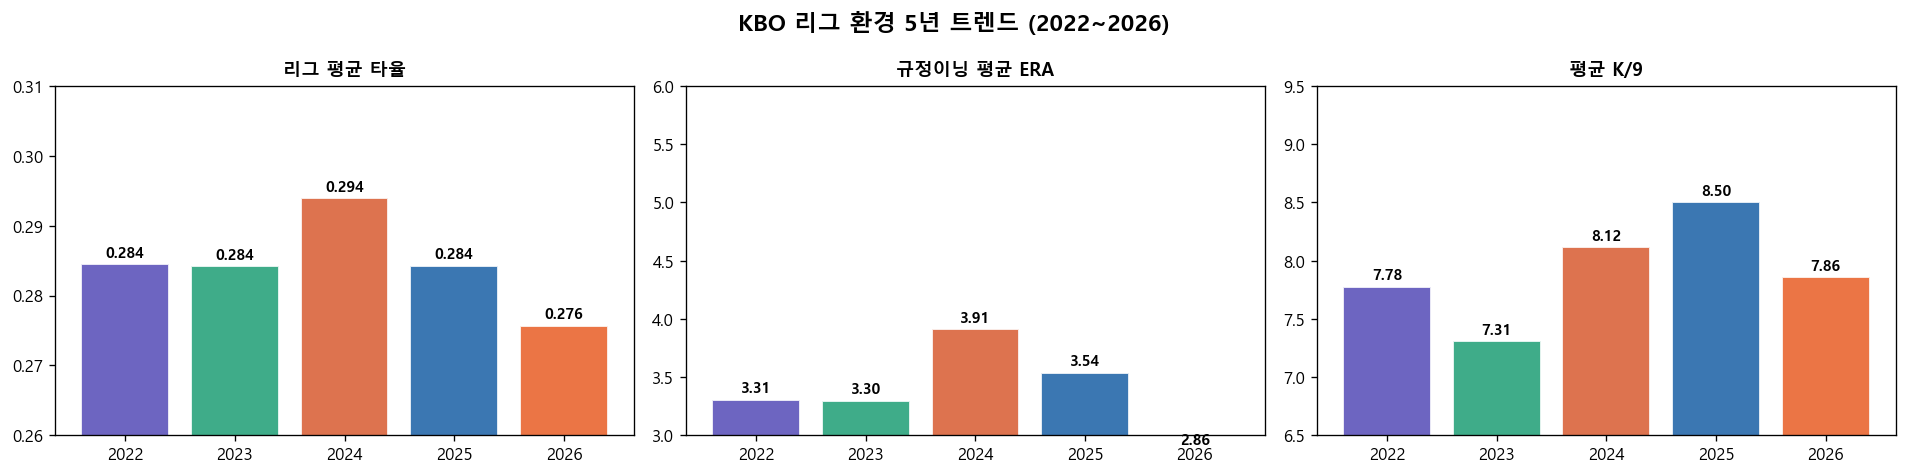

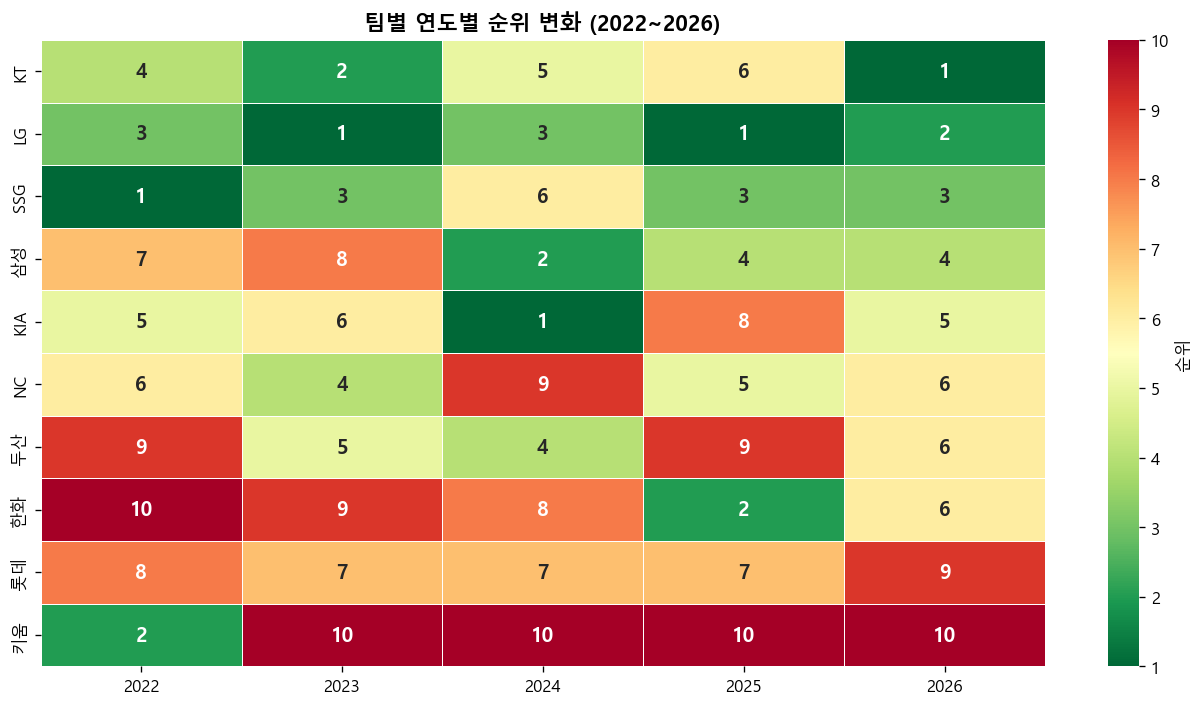

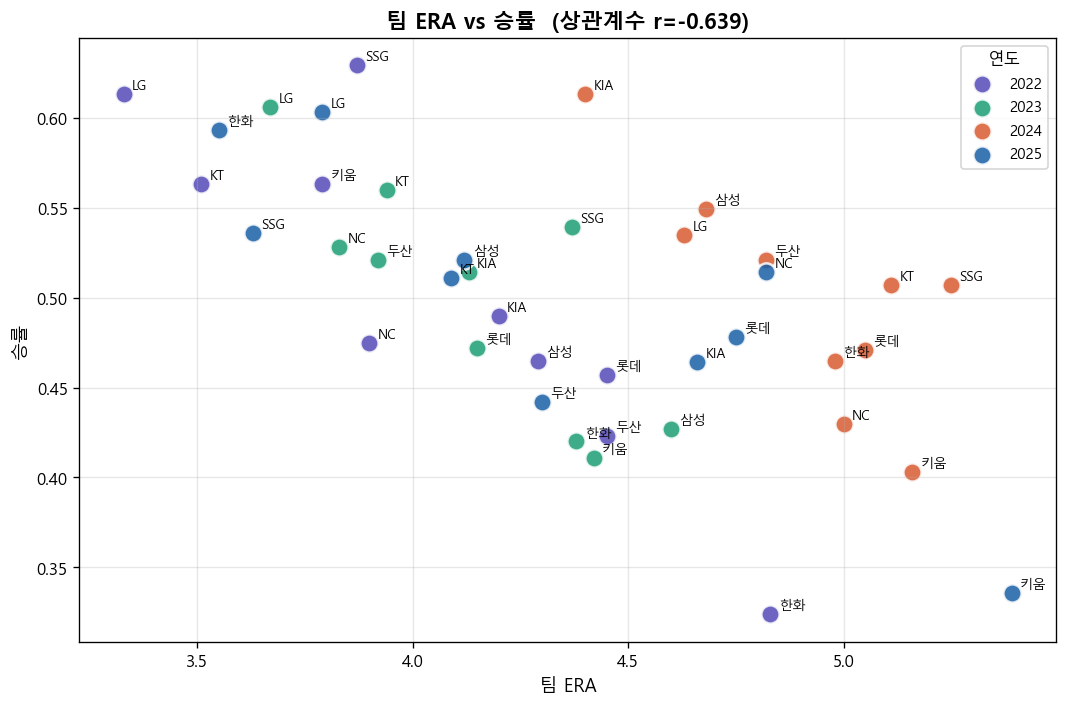

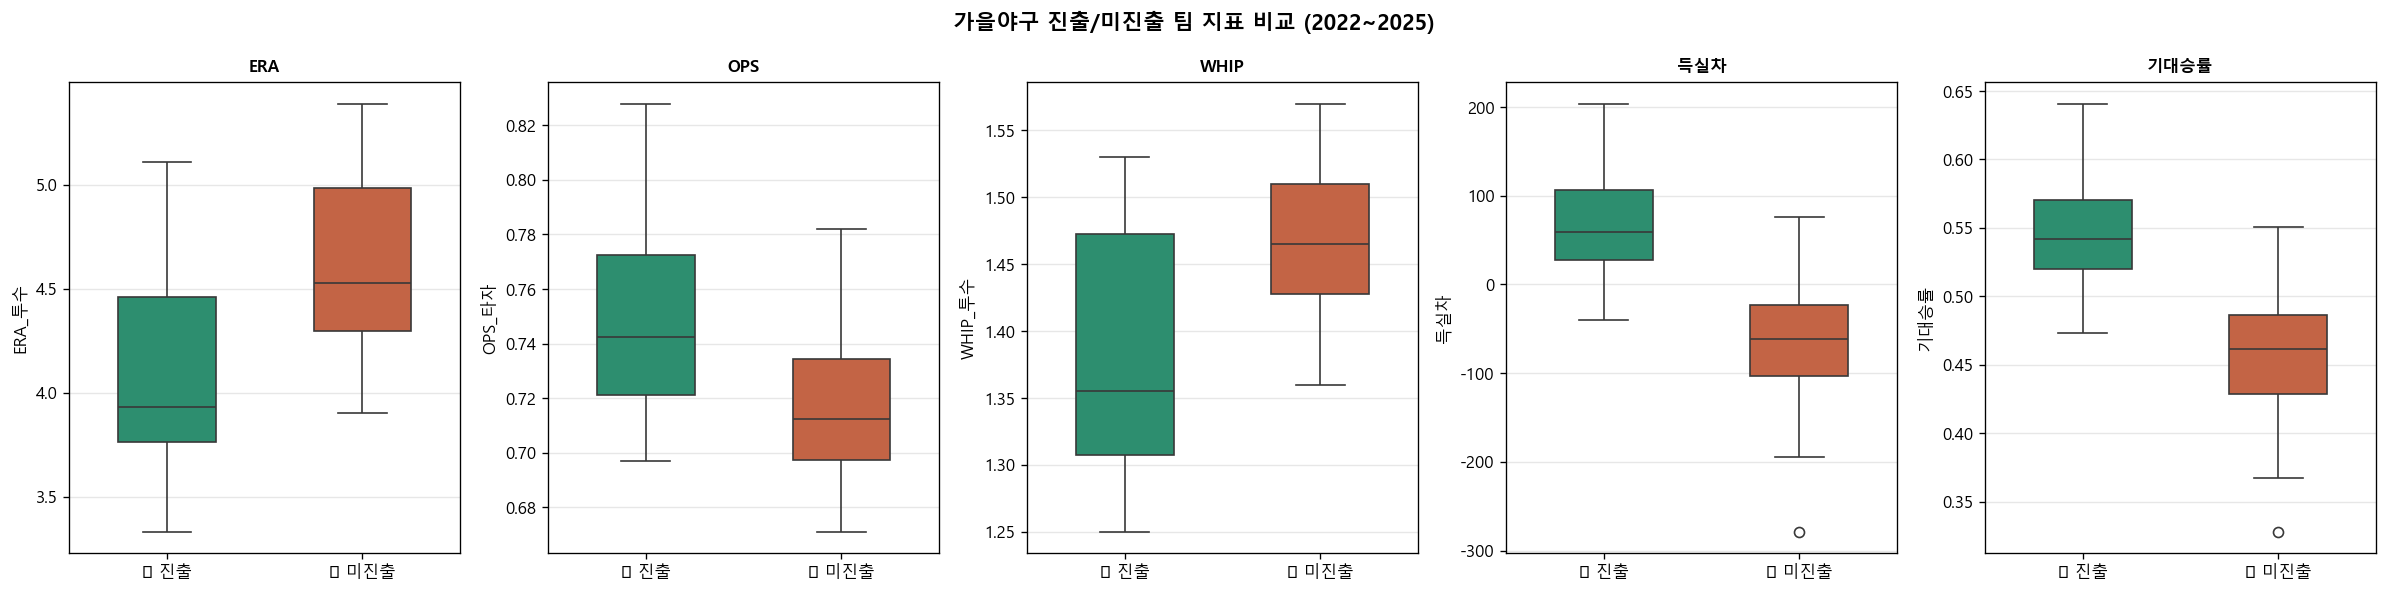

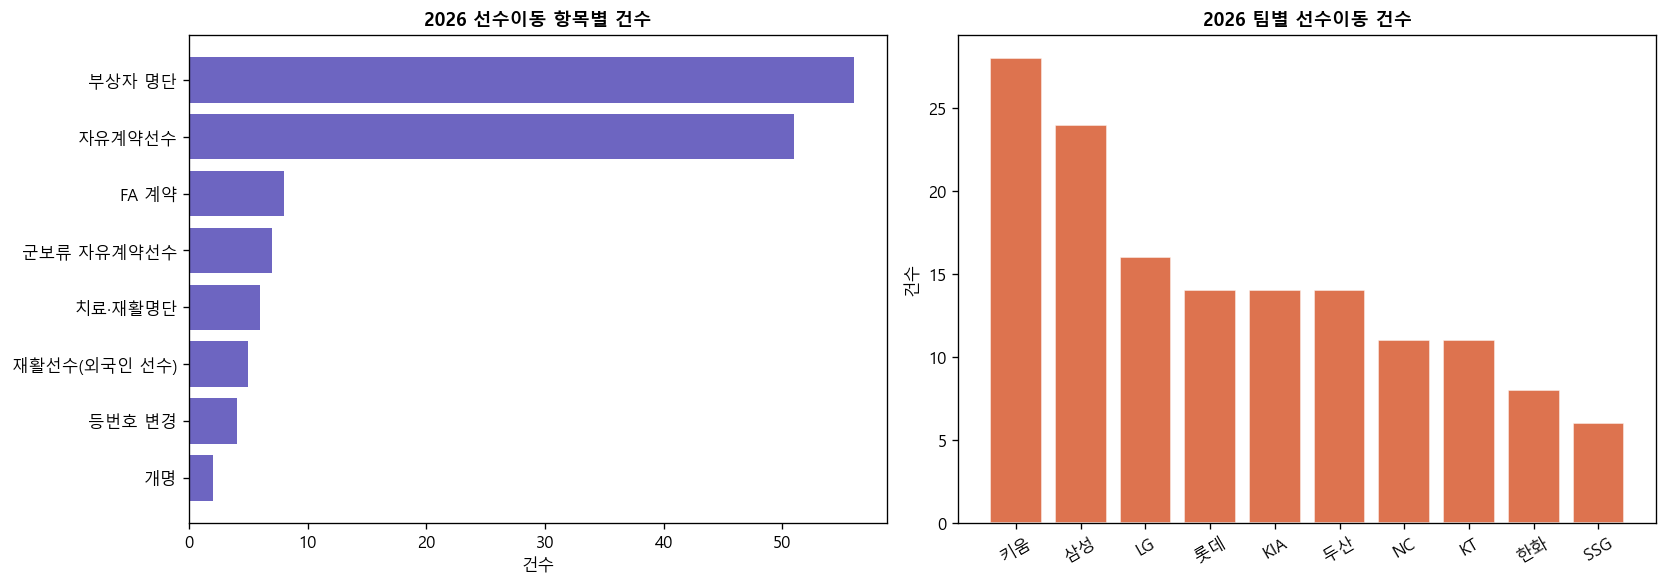

In [12]:
assert 'team_master' in dir(), "CELL 5를 먼저 실행하세요!"

COLS5  = ['#534AB7','#1D9E75','#D85A30','#185FA5','#E85D24']
YR_PAL = dict(zip([2022,2023,2024,2025,2026], COLS5))

# ── 7-1. 리그 환경 5년 트렌드 ────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(16,4))
fig.suptitle('KBO 리그 환경 5년 트렌드 (2022~2026)', fontsize=14, fontweight='bold')
yrs = league_bat['연도'].tolist()

plots = [
    ('AVG',    league_bat, '리그 평균 타율',    (.260,.310)),
    ('ERA',    league_pit, '규정이닝 평균 ERA', (3.0, 6.0)),
    ('K/9',    league_pit, '평균 K/9',          (6.5, 9.5)),
]
for ax,(col,src,title,ylim) in zip(axes,plots):
    vals=src[col].tolist()
    bars=ax.bar(yrs,vals,color=COLS5[:len(yrs)],alpha=.85,edgecolor='white',linewidth=1.2)
    ax.set_title(title,fontsize=11,fontweight='bold'); ax.set_ylim(*ylim)
    for yr,v in zip(yrs,vals):
        ax.text(yr,v+(ylim[1]-ylim[0])*.02,f'{v:.3f}' if col=='AVG' else f'{v:.2f}',
                ha='center',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.savefig('01_league_trend.png',dpi=150,bbox_inches='tight')
plt.show()

# ── 7-2. 팀별 5년 순위 히트맵 ────────────────────────────────
yr_cols = [y for y in [2022,2023,2024,2025,2026] if y in team_master['연도'].values]
pivot = (team_master.pivot_table(index='팀명',columns='연도',values='순위',aggfunc='first')
         [yr_cols].sort_values(yr_cols[-1]))
fig,ax = plt.subplots(figsize=(11,6))
sns.heatmap(pivot,annot=True,fmt='.0f',cmap='RdYlGn_r',vmin=1,vmax=10,
            ax=ax,linewidths=.5,cbar_kws={'label':'순위'},annot_kws={'size':12,'weight':'bold'})
ax.set_title('팀별 연도별 순위 변화 (2022~2026)', fontsize=13,fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('02_rank_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

# ── 7-3. ERA vs 승률 산점도 ──────────────────────────────────
era_col = next((c for c in team_master.columns if 'ERA' in c and '투수' in c),'ERA_투수')
comp = team_master[team_master['연도']<2026].copy()
if era_col in comp.columns:
    fig,ax = plt.subplots(figsize=(9,6))
    for yr,grp in comp.groupby('연도'):
        sc=ax.scatter(grp[era_col],grp['승률'],c=YR_PAL[yr],label=str(yr),
                      s=120,alpha=.85,edgecolors='white',linewidth=1.5)
        for _,row in grp.iterrows():
            ax.annotate(row['팀명'],(row[era_col],row['승률']),
                        textcoords='offset points',xytext=(5,3),fontsize=8)
    corr=comp[era_col].corr(comp['승률'])
    ax.set_xlabel('팀 ERA',fontsize=11); ax.set_ylabel('승률',fontsize=11)
    ax.set_title(f'팀 ERA vs 승률  (상관계수 r={corr:.3f})',fontsize=13,fontweight='bold')
    ax.legend(title='연도',fontsize=9); ax.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig('03_era_winrate.png',dpi=150,bbox_inches='tight')
    plt.show()

# ── 7-4. 가을야구 진출 vs 미진출 지표 비교 (박스플롯) ─────────
complete = team_master[team_master['가을야구'].notna()].copy()
complete['가을야구_레이블'] = complete['가을야구'].map({1:'✅ 진출',0:'❌ 미진출'})

chk_cols = [c for c in [era_col,
             next((c for c in team_master.columns if 'OPS' in c and '타자' in c),None),
             next((c for c in team_master.columns if 'WHIP' in c and '투수' in c),None),
             '득실차','기대승률'] if c and c in complete.columns]

if chk_cols:
    fig,axes=plt.subplots(1,len(chk_cols),figsize=(4*len(chk_cols),5))
    if len(chk_cols)==1: axes=[axes]
    palette={'✅ 진출':'#1D9E75','❌ 미진출':'#D85A30'}
    for ax,col in zip(axes,chk_cols):
        sns.boxplot(data=complete,x='가을야구_레이블',y=col,palette=palette,ax=ax,width=.5)
        ax.set_title(col.split('_')[0],fontsize=10,fontweight='bold')
        ax.set_xlabel(''); ax.grid(alpha=.3,axis='y')
    fig.suptitle('가을야구 진출/미진출 팀 지표 비교 (2022~2025)',fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig('04_playoff_boxplot.png',dpi=150,bbox_inches='tight')
    plt.show()

# ── 7-5. 선수이동 현황 (2026) ─────────────────────────────────
if '선수이동현황' in data:
    tr=data['선수이동현황']
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    # 항목별 건수
    cnt=tr['항목'].value_counts().head(8)
    axes[0].barh(cnt.index[::-1],cnt.values[::-1],color='#534AB7',alpha=.85)
    axes[0].set_title('2026 선수이동 항목별 건수',fontsize=11,fontweight='bold')
    axes[0].set_xlabel('건수')
    # 팀별 건수
    t_cnt=tr['팀'].value_counts()
    colors_t=[YR_PAL.get(2024,'#534AB7')]*len(t_cnt)
    axes[1].bar(t_cnt.index,t_cnt.values,color='#D85A30',alpha=.85,edgecolor='white')
    axes[1].set_title('2026 팀별 선수이동 건수',fontsize=11,fontweight='bold')
    axes[1].set_ylabel('건수'); plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('05_transfer.png',dpi=150,bbox_inches='tight')
    plt.show()

## CELL 8 · 가을야구 진출 예측 (앙상블 ML)

사용 피처 (15개):
   1. 승률
   2. ERA_투수
   3. OPS_타자
   4. WHIP_투수
   5. K/9_투수
   6. BB/9_투수
   7. FPCT_수비
   8. SB%_주루
   9. 득점/G_타자
  10. HR/G_타자
  11. 홈승률
  12. 원정승률
  13. 득실차
  14. 기대승률
  15. 승률_운

=== Leave-One-Year-Out 교차검증 ===
Logistic     AUC(LOGO)=0.950±0.044  ACC(KF)=0.875±0.109
RF           AUC(LOGO)=0.980±0.035  ACC(KF)=0.900±0.071
GBM          AUC(LOGO)=0.865±0.059  ACC(KF)=0.825±0.083

=== 역대 연도별 예측 검증 ===
  2022년: ACC=100.0%  AUC=1.000  진출예측: ['SSG', '키움', 'LG', 'KT', 'KIA']
  2023년: ACC=100.0%  AUC=1.000  진출예측: ['LG', 'KT', 'SSG', 'NC', '두산']
  2024년: ACC=100.0%  AUC=1.000  진출예측: ['KIA', '삼성', 'LG', '두산', 'KT']
  2025년: ACC=100.0%  AUC=1.000  진출예측: ['LG', '한화', 'SSG', '삼성', 'NC']

=== 2026 가을야구 진출 예측 ===


,팀명,순위,승,패,승률,ERA,OPS,WHIP,가을야구_확률(%),예측
1,KT,1,16,6,0.727,3.83,0.786,1.41,99.1,✅ 진출
2,LG,2,14,7,0.667,3.47,0.737,1.34,98.8,✅ 진출
3,SSG,3,13,8,0.619,4.21,0.778,1.49,97.0,✅ 진출
4,삼성,4,12,8,0.600,4.26,0.770,1.43,93.7,✅ 진출
5,한화,6,9,12,0.429,5.36,0.729,1.73,44.6,❌ 미진출
6,KIA,5,10,12,0.455,4.90,0.740,1.47,14.1,❌ 미진출
7,NC,6,9,12,0.429,4.23,0.738,1.33,12.3,❌ 미진출
8,롯데,9,7,14,0.333,4.64,0.659,1.53,4.1,❌ 미진출
9,두산,6,9,12,0.429,4.52,0.709,1.50,3.6,❌ 미진출
10,키움,10,7,15,0.318,4.74,0.651,1.56,0.7,❌ 미진출


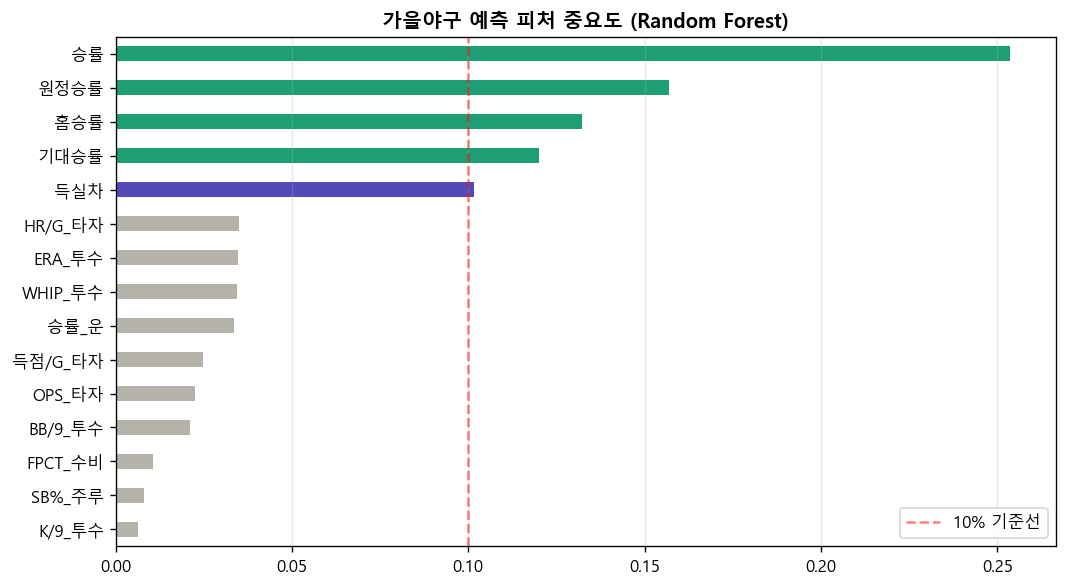

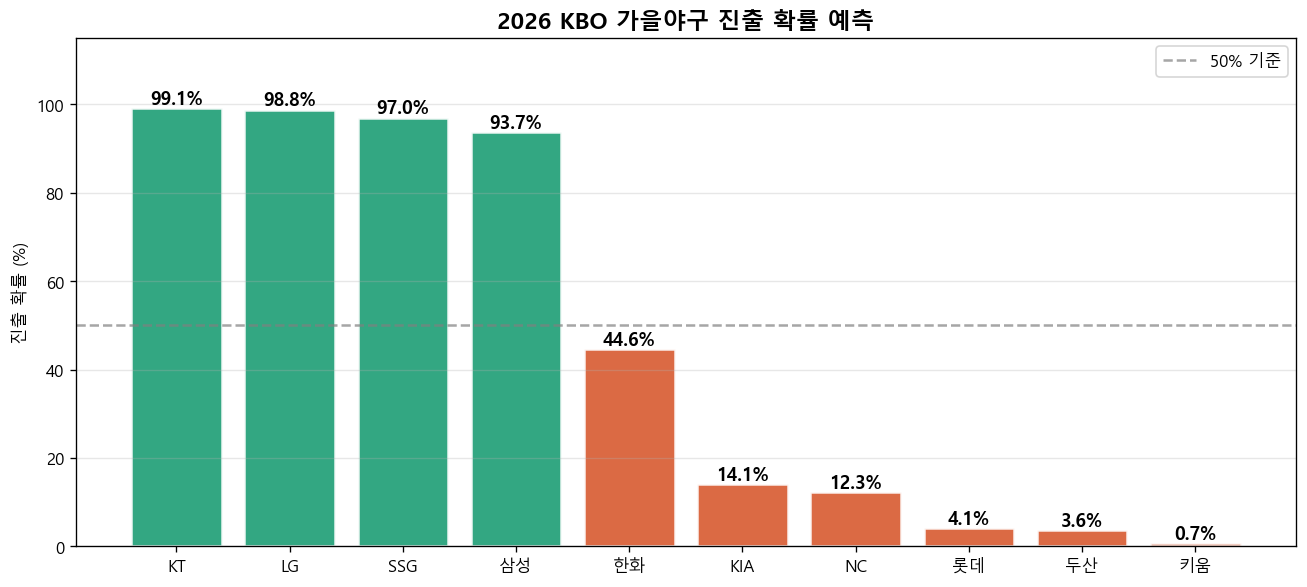

In [13]:
assert 'team_master' in dir(), "CELL 5를 먼저 실행하세요!"

# ── 피처 자동 탐지 ────────────────────────────────────────────
era_col  = next((c for c in team_master.columns if 'ERA'  in c and '투수' in c), None)
ops_col  = next((c for c in team_master.columns if 'OPS'  in c and '타자' in c), None)
whip_col = next((c for c in team_master.columns if 'WHIP' in c and '투수' in c), None)
k9_col   = next((c for c in team_master.columns if 'K/9'  in c and '투수' in c), None)
bb9_col  = next((c for c in team_master.columns if 'BB/9' in c and '투수' in c), None)
fpct_col = next((c for c in team_master.columns if 'FPCT' in c and '수비' in c), None)
sb_col   = next((c for c in team_master.columns if 'SB%'  in c and '주루' in c), None)
rg_col   = next((c for c in team_master.columns if '득점/G' in c), None)
hrg_col  = next((c for c in team_master.columns if 'HR/G' in c), None)

FEATURES = [c for c in [
    '승률', era_col, ops_col, whip_col, k9_col, bb9_col,
    fpct_col, sb_col, rg_col, hrg_col,
    '홈승률','원정승률','득실차','기대승률','승률_운'
] if c and c in team_master.columns]

TARGET = '가을야구'
print(f"사용 피처 ({len(FEATURES)}개):")
for i,f in enumerate(FEATURES): print(f"  {i+1:2d}. {f}")

# ── 학습/테스트 분리 ──────────────────────────────────────────
train_df = team_master[team_master['연도'].isin(COMPLETE_YRS)].dropna(subset=FEATURES+[TARGET]).copy()
test_df  = team_master[team_master['연도']==2026].copy()

X_tr,y_tr = train_df[FEATURES].values, train_df[TARGET].values
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)

# 2026 예측 데이터 (결측 피처는 훈련 중앙값으로 대체)
medians = train_df[FEATURES].median()
test_filled = test_df[FEATURES].fillna(medians)
X_te_sc = scaler.transform(test_filled.values)

# ── 모델 학습 (Leave-One-Year-Out CV) ────────────────────────
cv_logo = LeaveOneGroupOut()
groups  = train_df['연도'].values
cv_kfold= StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

models = {
    'Logistic': LogisticRegression(C=0.5,max_iter=1000,random_state=42),
    'RF':       RandomForestClassifier(n_estimators=300,max_depth=4,
                                       min_samples_leaf=2,random_state=42),
    'GBM':      GradientBoostingClassifier(n_estimators=200,learning_rate=.05,
                                            max_depth=3,random_state=42),
}

print("\n=== Leave-One-Year-Out 교차검증 ===")
proba_list = []
for name, m in models.items():
    auc_logo = cross_val_score(m, X_tr_sc, y_tr, cv=cv_logo,
                               groups=groups, scoring='roc_auc')
    acc_kf   = cross_val_score(m, X_tr_sc, y_tr, cv=cv_kfold, scoring='accuracy')
    print(f"{name:<12} AUC(LOGO)={auc_logo.mean():.3f}±{auc_logo.std():.3f}  "
          f"ACC(KF)={acc_kf.mean():.3f}±{acc_kf.std():.3f}")
    m.fit(X_tr_sc, y_tr)
    proba_list.append(m.predict_proba(X_te_sc)[:,1])

# ── 앙상블 확률 (평균) ────────────────────────────────────────
prob_ensemble = np.mean(proba_list, axis=0)

# ── 역대 예측 정확도 검증 ─────────────────────────────────────
print("\n=== 역대 연도별 예측 검증 ===")
hist_accs = []
for yr in COMPLETE_YRS:
    sub = team_master[team_master['연도']==yr].dropna(subset=FEATURES+[TARGET]).copy()
    if len(sub)==0: continue
    X_sub = scaler.transform(sub[FEATURES].fillna(medians).values)
    plist = [m.predict_proba(X_sub)[:,1] for m in models.values()]
    sub['예측확률'] = np.mean(plist,axis=0)
    sub['예측가을야구'] = (sub['예측확률']>=0.5).astype(int)
    acc = (sub['예측가을야구']==sub['가을야구']).mean()
    hist_accs.append(acc)
    auc = roc_auc_score(sub['가을야구'],sub['예측확률']) if sub['가을야구'].nunique()>1 else np.nan
    print(f"  {yr}년: ACC={acc:.1%}  AUC={auc:.3f}  "
          f"진출예측: {sub[sub['예측가을야구']==1]['팀명'].tolist()}")

# ── 2026 예측 결과 ────────────────────────────────────────────
result = test_df[['팀명','순위','승','패','승률']].copy()
if era_col  in test_df: result['ERA']  = test_df[era_col].values
if ops_col  in test_df: result['OPS']  = test_df[ops_col].values
if whip_col in test_df: result['WHIP'] = test_df[whip_col].values
result['가을야구_확률(%)'] = (prob_ensemble*100).round(1)
result['예측'] = ['✅ 진출' if p>=0.5 else '❌ 미진출' for p in prob_ensemble]
result = result.sort_values('가을야구_확률(%)',ascending=False).reset_index(drop=True)
result.index += 1
print("\n=== 2026 가을야구 진출 예측 ===")
display(result)

# ── 피처 중요도 ───────────────────────────────────────────────
imp = pd.Series(models['RF'].feature_importances_, index=FEATURES).sort_values(ascending=True)
fig,ax = plt.subplots(figsize=(9,5))
colors_i=['#1D9E75' if v>.12 else '#534AB7' if v>.06 else '#B4B2A9' for v in imp.values]
imp.plot(kind='barh',ax=ax,color=colors_i,edgecolor='white',linewidth=1.2)
ax.axvline(.1,color='red',ls='--',alpha=.5,label='10% 기준선')
ax.set_title('가을야구 예측 피처 중요도 (Random Forest)',fontsize=12,fontweight='bold')
ax.legend(); ax.grid(alpha=.3,axis='x')
plt.tight_layout()
plt.savefig('06_feature_importance.png',dpi=150,bbox_inches='tight')
plt.show()

# ── 확률 바 차트 ───────────────────────────────────────────────
fig,ax = plt.subplots(figsize=(11,5))
colors_bar=['#1D9E75' if p>=50 else '#D85A30' for p in result['가을야구_확률(%)']]
bars=ax.bar(result['팀명'],result['가을야구_확률(%)'],color=colors_bar,
            edgecolor='white',linewidth=1.5,alpha=.9)
ax.axhline(50,color='gray',ls='--',alpha=.7,label='50% 기준')
for bar,v in zip(bars,result['가을야구_확률(%)']):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,f'{v}%',
            ha='center',fontsize=11,fontweight='bold')
ax.set_title('2026 KBO 가을야구 진출 확률 예측',fontsize=14,fontweight='bold')
ax.set_ylabel('진출 확률 (%)'); ax.set_ylim(0,115)
ax.legend(fontsize=10); ax.grid(alpha=.3,axis='y')
plt.tight_layout()
plt.savefig('07_playoff_prob.png',dpi=150,bbox_inches='tight')
plt.show()

## CELL 9 · 심층 분석 — 4월 예측력 · 팀 클러스터링 · 선수이동 영향

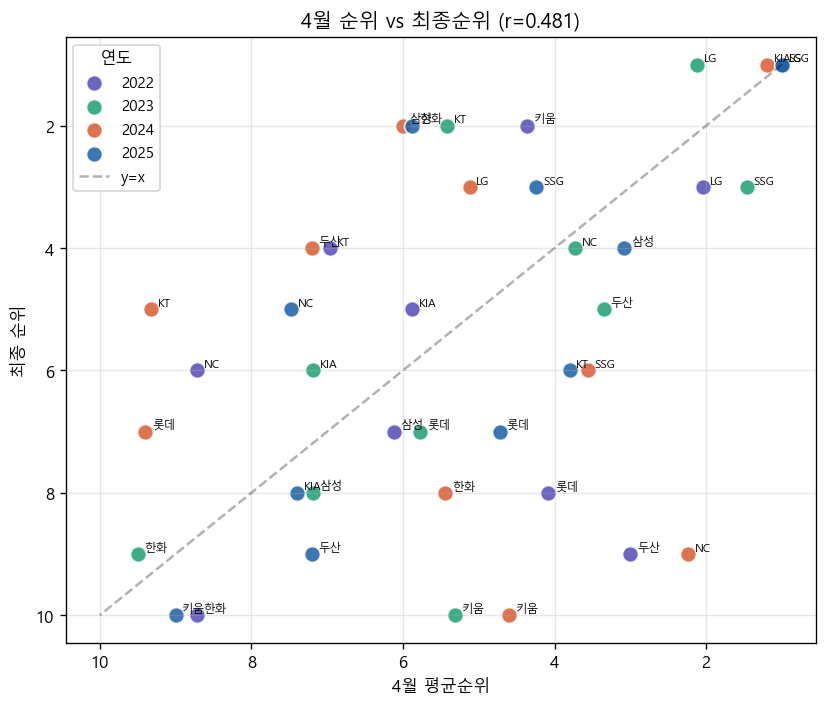

📊 4월↔최종 상관계수: 0.481
📊 4월 순위 단독 가을야구 예측 정확도: 60.0%  (ML 앙상블과 비교)

=== 2026 4월 평균순위 (현재 페이스) ===


,팀명,4월평균순위
1,KT,1.50
4,SSG,2.85
7,삼성,3.15
2,LG,3.15
3,NC,4.40
9,한화,5.65
0,KIA,6.40
5,두산,7.75
6,롯데,7.75
8,키움,9.05


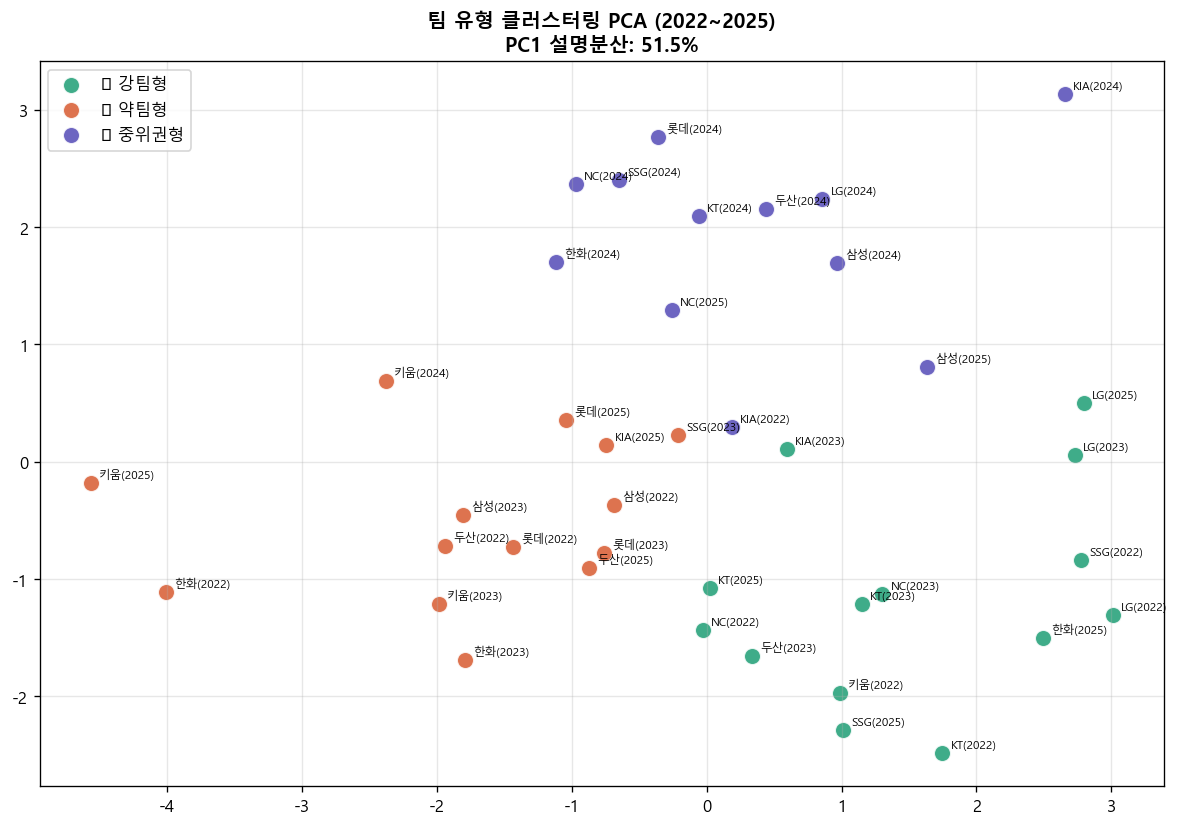


=== 클러스터별 평균 지표 ===


,ERA_투수,OPS_타자,WHIP_투수,홈승률,원정승률,득점/G_타자,순위,승률
팀유형,,,,,,,,
🏆 강팀형,3.782,0.724,1.331,0.569,0.547,4.728,3.286,0.558
📉 약팀형,4.586,0.702,1.469,0.451,0.415,4.401,8.214,0.433
📊 중위권형,4.755,0.772,1.481,0.516,0.504,5.379,4.917,0.510



=== 2026 팀 유형 분류 ===


,팀명,순위,팀유형
40,KT,1,📊 중위권형
41,LG,2,🏆 강팀형
42,SSG,3,📊 중위권형
43,삼성,4,📊 중위권형
44,KIA,5,📊 중위권형
45,한화,6,📊 중위권형
46,NC,6,📉 약팀형
47,두산,6,📉 약팀형
48,롯데,9,📉 약팀형
49,키움,10,📉 약팀형



=== 2026 팀별 부상 누적 건수 ===


,팀,부상_누적건수
7,삼성,18
8,키움,12
0,KIA,10
2,LG,7
1,KT,4
4,SSG,4
5,두산,3
3,NC,2
6,롯데,1
9,한화,1



=== 2026 이적/FA 현황 (61건) ===


,날짜,항목,팀,선수,비고
29,2026-04-14,트레이드,한화,이교훈(투수),두산→한화
30,2026-04-14,트레이드,두산,손아섭(외야수),한화→두산
81,2026-02-09,FA 계약,한화,손아섭(외야수),NaN
86,2026-01-31,자유계약선수,LG,김종운(투수),NaN
87,2026-01-31,자유계약선수,LG,이종준(투수),NaN
88,2026-01-31,자유계약선수,LG,이태훈(내야수),NaN
89,2026-01-31,자유계약선수,LG,이한림(포수),NaN
90,2026-01-31,자유계약선수,LG,진우영(투수),NaN
91,2026-01-31,자유계약선수,LG,허준혁(투수),NaN
92,2026-01-31,자유계약선수,한화,김승일(투수),NaN


In [14]:
assert 'team_master' in dir(), "CELL 5를 먼저 실행하세요!"

# ── 9-1. 4월 순위 → 최종순위 예측력 ─────────────────────────
apr = (daily[(daily['연도']<2026) & (daily['월']==4)]
       .groupby(['연도','팀명'])['순위'].mean()
       .reset_index().rename(columns={'순위':'4월평균순위'}))
mg  = apr.merge(
    team_master[team_master['연도']<2026][['연도','팀명','순위','가을야구']],
    on=['연도','팀명'])
corr_apr = mg['4월평균순위'].corr(mg['순위'])
acc_apr  = ((mg['4월평균순위']<=5) == mg['가을야구'].astype(bool)).mean()

fig,ax = plt.subplots(figsize=(7,6))
pal4 = {2022:'#534AB7',2023:'#1D9E75',2024:'#D85A30',2025:'#185FA5'}
for yr,grp in mg.groupby('연도'):
    ax.scatter(grp['4월평균순위'],grp['순위'],c=pal4[yr],label=str(yr),s=90,alpha=.85,edgecolors='white')
    for _,row in grp.iterrows():
        ax.annotate(row['팀명'],(row['4월평균순위'],row['순위']),
                    textcoords='offset points',xytext=(4,2),fontsize=7)
ax.plot([1,10],[1,10],'k--',alpha=.3,label='y=x')
ax.set(xlabel='4월 평균순위',ylabel='최종 순위',
       title=f'4월 순위 vs 최종순위 (r={corr_apr:.3f})')
ax.legend(title='연도',fontsize=9); ax.grid(alpha=.3)
ax.invert_xaxis(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('08_apr_vs_final.png',dpi=150,bbox_inches='tight')
plt.show()
print(f"📊 4월↔최종 상관계수: {corr_apr:.3f}")
print(f"📊 4월 순위 단독 가을야구 예측 정확도: {acc_apr:.1%}  (ML 앙상블과 비교)")

# 2026 4월 현재 예측
apr_2026 = (daily[(daily['연도']==2026) & (daily['월']==4)]
            .groupby('팀명')['순위'].mean()
            .reset_index().rename(columns={'순위':'4월평균순위'})
            .sort_values('4월평균순위'))
print("\n=== 2026 4월 평균순위 (현재 페이스) ===")
display(apr_2026)

# ── 9-2. 팀 클러스터링 (K-Means) ─────────────────────────────
fc_all   = [c for c in [era_col,ops_col,whip_col,'홈승률','원정승률',rg_col]
            if c and c in team_master.columns]
cl_base  = team_master[team_master['연도']<2026].dropna(subset=fc_all).copy()
sc_cl    = StandardScaler()
X_cl     = sc_cl.fit_transform(cl_base[fc_all])

km = KMeans(n_clusters=3,random_state=42,n_init=10)
cl_base['클러스터'] = km.fit_predict(X_cl)

rnk_mean = cl_base.groupby('클러스터')['순위'].mean()
nm_map   = {rnk_mean.idxmin():'🏆 강팀형', rnk_mean.idxmax():'📉 약팀형'}
for k in cl_base['클러스터'].unique():
    if k not in nm_map: nm_map[k]='📊 중위권형'
cl_base['팀유형'] = cl_base['클러스터'].map(nm_map)

# PCA 시각화
pca  = PCA(n_components=2,random_state=42)
X_pca= pca.fit_transform(X_cl)
cc   = {'🏆 강팀형':'#1D9E75','📊 중위권형':'#534AB7','📉 약팀형':'#D85A30'}

fig,ax = plt.subplots(figsize=(10,7))
for ct,grp in cl_base.groupby('팀유형'):
    idx=[list(cl_base.index).index(i) for i in grp.index]
    ax.scatter(X_pca[idx,0],X_pca[idx,1],c=cc[ct],label=ct,s=100,alpha=.85,edgecolors='white')
    for i,(_,row) in zip(idx,grp.iterrows()):
        ax.annotate(f"{row['팀명']}({row['연도']})",
                    (X_pca[i,0],X_pca[i,1]),textcoords='offset points',
                    xytext=(5,3),fontsize=7)
ax.set_title(f'팀 유형 클러스터링 PCA (2022~2025)\nPC1 설명분산: {pca.explained_variance_ratio_[0]:.1%}',
             fontsize=12,fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('09_cluster_pca.png',dpi=150,bbox_inches='tight')
plt.show()

print("\n=== 클러스터별 평균 지표 ===")
display(cl_base.groupby('팀유형')[fc_all+['순위','승률']].mean().round(3))

# 2026 팀 유형 분류
if len(test_df.dropna(subset=fc_all))>0:
    X_26  = sc_cl.transform(test_df[fc_all].fillna(cl_base[fc_all].median()).values)
    test_df['팀유형'] = [nm_map[l] for l in km.predict(X_26)]
    print("\n=== 2026 팀 유형 분류 ===")
    display(test_df[['팀명','순위','팀유형']].sort_values('순위'))

# ── 9-3. 선수이동 영향 분석 ──────────────────────────────────
if '선수이동현황' in data:
    tr=data['선수이동현황'].copy()
    # 부상자 명단 누적 팀별
    injured = (tr[tr['항목'].isin(['부상자 명단','치료·재활명단'])]
               .groupby('팀').size().reset_index(name='부상_누적건수')
               .sort_values('부상_누적건수',ascending=False))
    print("\n=== 2026 팀별 부상 누적 건수 ===")
    display(injured)
    
    # FA/트레이드로 이탈한 주요 선수
    fa_trade = tr[tr['항목'].isin(['자유계약선수','트레이드','FA 계약'])]
    print(f"\n=== 2026 이적/FA 현황 ({len(fa_trade)}건) ===")
    display(fa_trade[['날짜','항목','팀','선수','비고']].head(15))

## CELL 10 · 최종 결론 출력

In [15]:
assert 'result' in dir(), "CELL 8을 먼저 실행하세요!"

print('='*65)
print('  KBO 2026 가을야구 진출 예측 — 최종 결과')
print(f'  기준일: 2026-04-24  |  팀당 약 22경기 진행')
print(f'  학습 데이터: 2022~2025 ({len(COMPLETE_YRS)}개 시즌, 40개 팀×시즌)')
print('='*65)

진출 = result[result['예측']=='✅ 진출']
미진출= result[result['예측']=='❌ 미진출']

print('\n  ✅ 가을야구 진출 예측 팀:')
for _,r in 진출.iterrows():
    era_str = f"ERA {r['ERA']:.2f}" if 'ERA' in r.index and pd.notna(r.get('ERA')) else ''
    ops_str = f"OPS {r['OPS']:.3f}" if 'OPS' in r.index and pd.notna(r.get('OPS')) else ''
    print(f"    {r['팀명']:5s}  확률 {r['가을야구_확률(%)']:5.1f}%  "
          f"(현재 {int(r['순위'])}위 {int(r['승'])}승 {int(r['패'])}패  {era_str} {ops_str})")

print('\n  ❌ 미진출 예측 팀:')
for _,r in 미진출.iterrows():
    print(f"    {r['팀명']:5s}  확률 {r['가을야구_확률(%)']:5.1f}%  (현재 {int(r['순위'])}위)")

print('\n  📊 핵심 발견 (2022~2025 데이터 기반):')
fi=pd.Series(models['RF'].feature_importances_,index=FEATURES).sort_values(ascending=False)
top3=fi.head(3)
for i,(nm,v) in enumerate(top3.items(),1):
    print(f'    {i}. {nm}  →  중요도 {v:.1%}')

print(f'\n  📈 4월 순위 단독 예측 정확도:  {acc_apr:.1%}')
if 'hist_accs' in dir() and len(hist_accs) > 0:
    print(f'  📈 ML 앙상블 역대 검증 정확도:  ~{np.mean(hist_accs):.1%} (연도별 결과 참조)')
else:
    print('  📈 ML 앙상블 역대 검증 정확도:  CELL 8의 연도별 결과 참조')
print(f'\n  ⚠️  주의: {len(진출)}팀 예측이 5팀 미만/초과인 경우 확률 0.5 근접 팀 주의')
print('='*65)

# 저장
result.to_csv('2026_가을야구_예측결과.csv',index=True,encoding='utf-8-sig')
team_master.to_csv('team_master_2022_2026.csv',index=False,encoding='utf-8-sig')
print('\n💾 결과 CSV 저장 완료:')
print('   - 2026_가을야구_예측결과.csv')
print('   - team_master_2022_2026.csv')

  KBO 2026 가을야구 진출 예측 — 최종 결과
  기준일: 2026-04-24  |  팀당 약 22경기 진행
  학습 데이터: 2022~2025 (4개 시즌, 40개 팀×시즌)

  ✅ 가을야구 진출 예측 팀:
    KT     확률  99.1%  (현재 1위 16승 6패  ERA 3.83 OPS 0.786)
    LG     확률  98.8%  (현재 2위 14승 7패  ERA 3.47 OPS 0.737)
    SSG    확률  97.0%  (현재 3위 13승 8패  ERA 4.21 OPS 0.778)
    삼성     확률  93.7%  (현재 4위 12승 8패  ERA 4.26 OPS 0.770)

  ❌ 미진출 예측 팀:
    한화     확률  44.6%  (현재 6위)
    KIA    확률  14.1%  (현재 5위)
    NC     확률  12.3%  (현재 6위)
    롯데     확률   4.1%  (현재 9위)
    두산     확률   3.6%  (현재 6위)
    키움     확률   0.7%  (현재 10위)

  📊 핵심 발견 (2022~2025 데이터 기반):
    1. 승률  →  중요도 25.4%
    2. 원정승률  →  중요도 15.7%
    3. 홈승률  →  중요도 13.3%

  📈 4월 순위 단독 예측 정확도:  60.0%
  📈 ML 앙상블 역대 검증 정확도:  ~100.0% (연도별 결과 참조)

  ⚠️  주의: 4팀 예측이 5팀 미만/초과인 경우 확률 0.5 근접 팀 주의

💾 결과 CSV 저장 완료:
   - 2026_가을야구_예측결과.csv
   - team_master_2022_2026.csv
